In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#reading csv file
df_subject=pd.read_csv('subject-info.csv')
df_test=pd.read_csv('test_measure.csv')

In [16]:
#34. Create an array , np.arange(12).reshape(3,4). Replace the array elements with their square values if the element is an even number. Keep the odd numbers as such. Display the resulting array.

# Creating an array
array_original=np.arange(12).reshape(3,4)

#Using np.where condition
resulting_array=np.where(array_original%2==0, np.square(array_original), array_original)

print(resulting_array)

[[  0   1   4   3]
 [ 16   5  36   7]
 [ 64   9 100  11]]


In [17]:
#35. Read 10 records from dataframe and convert into json format and print the data

first_ten_records=df_subject.head(10)

#converting into JSON Format
json_data = first_ten_records.to_json(orient='records', lines=True)
print(json_data)

{"Age":10.8,"Weight":48.8,"Height":163.0,"Humidity":39.0,"Temperature":20.7,"Sex":1,"ID":543,"ID_test":"543_1"}
{"Age":11.8,"Weight":41.0,"Height":150.0,"Humidity":41.0,"Temperature":22.3,"Sex":1,"ID":11,"ID_test":"11_1"}
{"Age":12.2,"Weight":46.0,"Height":160.0,"Humidity":37.0,"Temperature":21.5,"Sex":0,"ID":829,"ID_test":"829_1"}
{"Age":13.2,"Weight":71.0,"Height":190.0,"Humidity":49.0,"Temperature":23.8,"Sex":1,"ID":284,"ID_test":"284_1"}
{"Age":13.7,"Weight":53.8,"Height":169.7,"Humidity":40.0,"Temperature":25.3,"Sex":0,"ID":341,"ID_test":"341_1"}
{"Age":13.8,"Weight":53.4,"Height":171.0,"Humidity":42.0,"Temperature":24.4,"Sex":0,"ID":341,"ID_test":"341_2"}
{"Age":14.0,"Weight":46.0,"Height":160.0,"Humidity":40.0,"Temperature":25.3,"Sex":0,"ID":343,"ID_test":"343_1"}
{"Age":14.1,"Weight":50.0,"Height":168.9,"Humidity":42.0,"Temperature":24.2,"Sex":0,"ID":330,"ID_test":"330_1"}
{"Age":14.1,"Weight":47.2,"Height":160.2,"Humidity":40.0,"Temperature":25.2,"Sex":0,"ID":338,"ID_test":"33

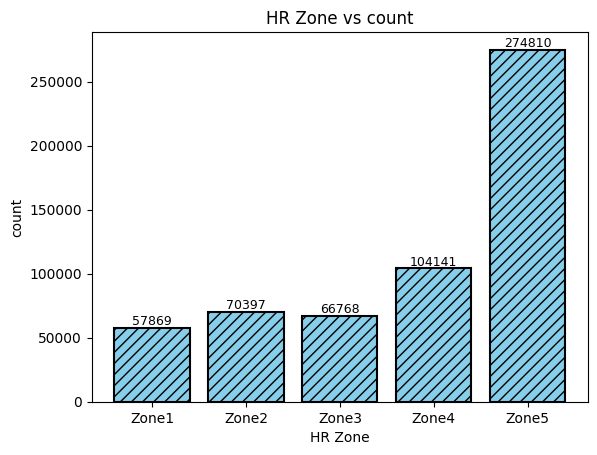

In [39]:
#36. Create a barchart for HR Zone vs count and apply hatches to the bars.

#removing rows that has missing values in HR Column
df_test = df_test.dropna(subset=['HR']) 

#hr-zones based on Q)23
def hr_zones(hr):
    if hr<100:
        return "Zone1"   #-(recovery/easy)
    elif hr<120:
        return "Zone2"   #-(aerobic/base)
    elif hr<135:
        return "Zone3"   #-(tempo)
    elif hr<155:
        return "Zone4"   #-(lactate threshold)
    else:
        return "Zone5"   #-(anaerobic)

#applying to each row
df_test['hr_zones']=df_test['HR'].apply(hr_zones)

#count of zone in each row
count_of_zone = df_test['hr_zones'].value_counts().sort_index()

# Plotting Bar Chart
bars = plt.bar(count_of_zone.index, count_of_zone.values,hatch='///', color='skyblue', edgecolor='black', linewidth=1.5)

# Label the bars
for bar in bars:
    yval = bar.get_height()  # Get the height (value) of each bar
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, str(int(yval)), 
             ha='center', va='bottom', fontsize=9)

#Plotting Bar Chart
plt.xlabel("HR Zone") 
plt.ylabel("count")
plt.title("HR Zone vs count")
plt.show()

In [50]:
#37.Who is the youngest athlete and how many tests did she take part in?

#Only rows where gender is female which is 1
female_athlete = df_subject[df_subject['Sex'] == 1]

#youngest athlete whose age is minimum
youngest_athlete = female_athlete['Age'].min()

#finding the youngest female athlete row
youngest_female_athlete=female_athlete[female_athlete['Age'] == youngest_athlete].iloc[0]

#getting her ID
youngest_female_athlete_ID=youngest_female_athlete['ID']

print(f"Youngest female athlete ID is:{youngest_female_athlete_ID} and her age is {youngest_athlete}")

#no of tests she took part 
no_of_tests = df_test[df_test['ID'] == youngest_female_athlete_ID]
total_tests = no_of_tests.shape[0]

print(f"No of tests She took part in: {total_tests}")

Youngest female athlete ID is:543 and her age is 10.8
No of tests She took part in: 676


In [ ]:
#40.Identify the test that took the longest time to complete.

#longest time
longest_time=df_test['time'].max()

#finding the test  with longest time
longest_test = df_test[df_test['time'] == longest_time]

print(longest_test)

        time  Speed    HR     VO2    VCO2    RR    VE ID_test   ID
475707  1712    4.9  90.0  1293.0  1575.0  24.0  46.6   699_1  699


In [ ]:

#41. Perform an EDA of subject_info using YDATA Profiling.

###Use python version below 3.13.0

###Installing the package
#pip install ydata-profiling

###Import the libraries
#import pandas as pd
#from ydata_profiling import ProfileReport

###Read the data
#df_subject = pd.read_csv("subject_info.csv")

###Generate Profile Report
###subject_info_report = ProfileReport(df_subject, title="EDA of subject_info", explorative=True)
#subject_info_report = ProfileReport(df_subject, title = "EDA of subject_info")

###subject_info_report.to_file(output_file = 'Report_subject_info.html')
###For Jupyter Notebook -profile.to_notebook_iframe()

### Display the report in the notebook
#subject_info_report.to_notebook_iframe()


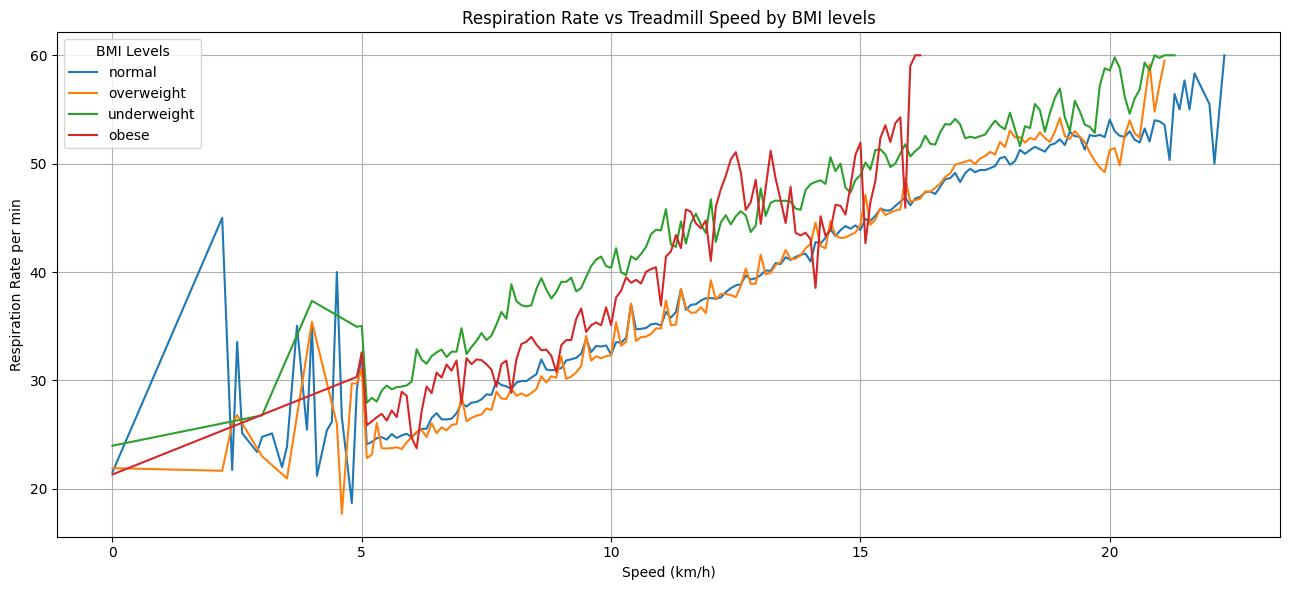


 *BMI level with highest average respiratory rate is:*
underweight level with 39.79 per min


In [ ]:
#42.How does respiration rate progress based on treadmill speed for different BMI levels? Visualize this relationship and find which BMI level has the highest mean respiration rate?"

# Convert height from cm to meters
df_subject['Height_m'] = df_subject['Height'] / 100

# Calculate BMI
df_subject['BMI'] = df_subject['Weight'] / (df_subject['Height_m'] ** 2)

#merge on participant ID
df_merge = pd.merge(df_test,df_subject, on='ID')

#BMI Levels
def bmi_levels(bmi):
    if bmi<18.5:
        return 'underweight'
    elif bmi<25:
        return 'normal'
    elif bmi<30:
        return 'overweight'
    else:
        return 'obese'
   
df_merge['BMI levels'] = df_merge['BMI'].apply(bmi_levels)

#visualizing relation between respiration rate and treadmill
plt.figure(figsize=(13,6))
sns.lineplot(data=df_merge, x='Speed', y='RR', hue='BMI levels',errorbar=None)
plt.title("Respiration Rate vs Treadmill Speed by BMI levels")
plt.xlabel("Speed (km/h)")
plt.ylabel("Respiration Rate per min")
plt.legend(title="BMI Levels")
plt.grid(True)
plt.tight_layout()
plt.show()

#BMI level with highest average Resp Rate
mean_highest_avg_rr = df_merge.groupby('BMI levels')['RR'].mean()

print("\n *BMI level with highest average respiratory rate is:*")
print(f"{mean_highest_avg_rr.idxmax()} level", "with", round(mean_highest_avg_rr.max(), 2), "per min")


In [47]:
#43. Identify cases of possible bradycardia at rest and display number of athletes based on gender.

#bradycardia - slow heart rate<60
bradycardia_df = df_test[df_test['HR'] < 60]

df_merge['Gender'] = df_merge['Sex'].map({0: 'Male:0', 1: 'Female:1'})

#no.of athletes based on gender
no_of_athletes=df_merge['Gender'].value_counts()

print(f"no of athletes with possible bradycardia cases are:")
print(no_of_athletes)

no of athletes with possible bradycardia cases are:
Gender
Male:0      676741
Female:1     96877
Name: count, dtype: int64


In [ ]:
#Repeating 2nd time, will delte later
#43. Identify cases of possible bradycardia at rest and display number of athletes based on gender.

#bradycardia - slow heart rate<60
bradycardia_df = df_test[df_test['HR'] < 60]

#no.of athletes based on gender
no_of_athletes=df_merge['Sex'].value_counts()

print("No of athletes with possible bradycardia cases are:")
print(no_of_athletes)

No of athletes with possible bradycardia cases are:
Sex
0    676741
1     96877
Name: count, dtype: int64


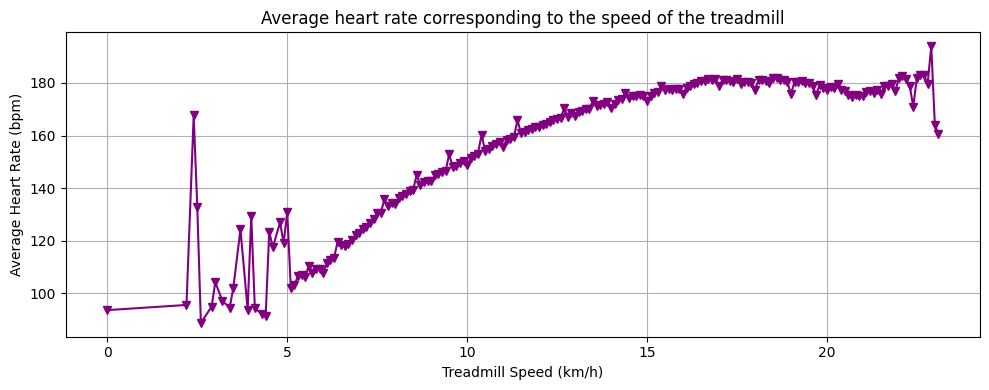

In [ ]:
#44. Calculate the average heart rate corresponding to the speed of the treadmill and  plot a line graph to visualize the relationship.

avg_heart_rate=df_test.groupby('Speed')['HR'].mean()

#plotting the line graph
plt.figure(figsize=(10,4))
plt.plot(avg_heart_rate.index,avg_heart_rate.values, marker='v', linestyle='-', color='purple')
plt.title("Average heart rate corresponding to the speed of the treadmill")
plt.xlabel("Treadmill Speed (km/h)")
plt.ylabel("Average Heart Rate (bpm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#47 Assuming age is given for the current year(2025) , list the participants born on leap year

#calculate year of birth
df_subject['Year of Birth']= 2025 - df_subject['Age']

#leap year
def leap_year(year):
    if year % 4 == 0:
        if year % 100 == 0:
            if year % 400 == 0:
                return True
            else:
                return False
        return True
    return False

df_subject['leap_year_born'] = df_subject['Year of Birth'].apply(leap_year)

#participants born in leap year
leap_year_participants=df_subject[df_subject['leap_year_born'] == True]

#list of participants
print("Participants born in leap years:")
print(leap_year_participants[['ID', 'Age', 'Year of Birth']])

Participants born in leap years:
      ID   Age  Year of Birth
113  177  17.0         2008.0
114  303  17.0         2008.0
115  346  17.0         2008.0
116  637  17.0         2008.0
244   83  21.0         2004.0
245  458  21.0         2004.0
246  773  21.0         2004.0
404   84  25.0         2000.0
405  183  25.0         2000.0
406  255  25.0         2000.0
407  263  25.0         2000.0
408  353  25.0         2000.0
409  391  25.0         2000.0
410  493  25.0         2000.0
555  491  29.0         1996.0
556  566  29.0         1996.0
557  857  29.0         1996.0
664  103  33.0         1992.0
665  763  33.0         1992.0
764   95  37.0         1988.0
765  196  37.0         1988.0
766  236  37.0         1988.0
767  253  37.0         1988.0
768  630  37.0         1988.0
769  632  37.0         1988.0
852  101  41.0         1984.0
853  363  41.0         1984.0
917  450  45.0         1980.0


28